# A first look at five years of store-item sales

Exploratory only. The production replay lives in `src/` and runs with `python -m src.pipeline`. The question here: what kind of change should a drift monitor expect in this data, and what kind should it ignore?

In [1]:
import sys
sys.path.insert(0, '..')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import wasserstein_distance

from src.ingest.load import load_sales

plt.rcParams.update({'font.family': 'Segoe UI', 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.edgecolor': '#c3c2b7',
                     'figure.dpi': 110})

sales = load_sales('../data/train.csv')
print(f"{len(sales):,} rows: {sales['store'].nunique()} stores x "
      f"{sales['item'].nunique()} items x {sales['date'].nunique():,} days, no gaps")

913,000 rows: 10 stores x 50 items x 1,826 days, no gaps


## Sales grow every year

In [2]:
yearly = sales.groupby(sales['date'].dt.year)['sales'].agg(['mean', 'median', 'std'])
yearly['growth vs previous year'] = yearly['mean'].pct_change()
yearly.style.format({'mean': '{:.1f}', 'median': '{:.0f}', 'std': '{:.1f}',
                     'growth vs previous year': '{:+.1%}'}, na_rep='')

,mean,median,std,growth vs previous year
date,,,,
2013,43.5,39,23.6,
2014,50.1,45,27.0,+15.0%
2015,52.3,47,28.2,+4.4%
2016,56.6,51,30.4,+8.3%
2017,58.8,53,31.6,+3.9%


## ...on top of a strong seasonal pattern

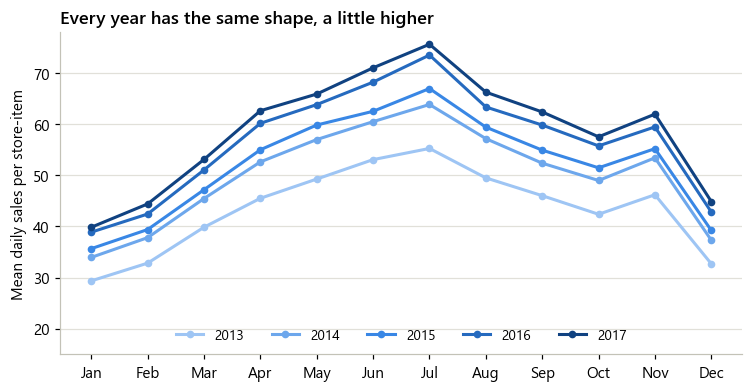

In [3]:
by_month = (sales.assign(year=sales['date'].dt.year, month=sales['date'].dt.month)
            .groupby(['year', 'month'])['sales'].mean().unstack(0))
ramp = ['#9ec5f4', '#6da7ec', '#3987e5', '#256abf', '#104281']  # one hue, light = older
fig, ax = plt.subplots(figsize=(8, 3.8))
for color, year in zip(ramp, by_month.columns):
    ax.plot(by_month.index, by_month[year], color=color, linewidth=2, marker='o',
            markersize=4, label=str(year))
ax.set_xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug',
                             'Sep', 'Oct', 'Nov', 'Dec'])
ax.set_ylabel('Mean daily sales per store-item')
ax.set_title('Every year has the same shape, a little higher', loc='left',
             fontweight='semibold')
ax.grid(axis='y', color='#e1e0d9', linewidth=0.8); ax.set_axisbelow(True)
ax.set_ylim(15, None)  # room for the legend under the lines
ax.legend(frameon=False, fontsize=9, ncol=5, loc='lower center')
plt.show()

In [4]:
weekday = sales.groupby(sales['date'].dt.day_name())['sales'].mean()
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
(weekday[order] / weekday.mean()).rename('index vs average day').round(2).to_frame().T

date,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
index vs average day,0.79,0.92,0.93,0.99,1.06,1.12,1.19


## Why a naive drift check cries wolf

Evidently's default test for a numeric column this size is the Wasserstein distance divided by the reference's standard deviation, flagged at 0.1. Compare July 2016 with all of 2015, and then with July 2015:

In [5]:
def drift(current, reference):
    return wasserstein_distance(reference, current) / np.std(reference)

def month(year, m):
    return sales[(sales['date'].dt.year == year) & (sales['date'].dt.month == m)]['sales']

all_2015 = sales[sales['date'].dt.year == 2015]['sales']
pd.DataFrame({
    'vs all of 2015 (naive)': [drift(month(2016, m), all_2015) for m in (1, 4, 7, 10)],
    'vs same month of 2015': [drift(month(2016, m), month(2015, m)) for m in (1, 4, 7, 10)],
}, index=['Jan 2016', 'Apr 2016', 'Jul 2016', 'Oct 2016']).round(3)

,vs all of 2015 (naive),vs same month of 2015
Jan 2016,0.476,0.179
Apr 2016,0.280,0.189
Jul 2016,0.753,0.198
Oct 2016,0.129,0.166


## What this means for the monitor

- **The real change is slow growth.** Average daily sales rise every year, by 15% in 2014 and then between 4% and 8%. A model trained on 2013–2015 that can't see recent sales will fall behind by roughly that much each year, without its errors looking unusual.
- **The seasonal pattern is much bigger than the growth.** July runs 28% above the yearly average, December 25% and January 32% below, and Sunday sells 50% more than Monday. Any drift check has to see past that.
- **So the reference has to be seasonal.** Against all of 2015, the drift score for 2016 swings from 0.13 in October to 0.75 in July, purely because of the season. Against the same month of 2015 it sits steadily between 0.17 and 0.20, which is the 8% growth. The monitor in `src/monitoring/drift.py` uses that comparison.
- **The data is complete and clean.** 500 series, one row per day, no gaps. Nothing here needs cleaning before the replay, so any drift the monitor finds is real change in demand, not a data problem.
